# Chủ đề: Đánh đổi giữa tăng trưởng kinh tế - môi trường (Kuznets) và chuyển dịch năng lượng toàn cầu

## Bối cảnh dữ liệu
Dataset sử dụng là bộ chỉ số **World Development Indicators (WDI)**, phản ánh đồng thời ba trục chính của đề tài:
- **Kinh tế:** GDP bình quân đầu người, tăng trưởng GDP, tỷ trọng công nghiệp.
- **Năng lượng:** mức dùng năng lượng, tỷ lệ năng lượng tái tạo, tiếp cận điện, tiếp cận nhiên liệu sạch.
- **Môi trường & xã hội:** phát thải CO2 bình quân đầu người, diện tích rừng, dân số.

Dữ liệu ở dạng bảng rộng (wide format): mỗi dòng là một tổ hợp `(quốc gia/vùng lãnh thổ, chỉ số)`, các cột năm lưu giá trị theo chuỗi thời gian.

## Mục tiêu
1. Mô tả cấu trúc dữ liệu và quy mô dữ liệu đầu vào.
2. Kiểm tra chất lượng dữ liệu thô (schema, missing, dòng rác).
3. Chuẩn hóa dữ liệu ở mức cần thiết để tạo dataset nền cho các giai đoạn sau.

## Nguồn dữ liệu
- File chính: `Data/Dataset.csv`.
- File tham chiếu chỉ số: `Data/Series-Metadata.csv`.

## 1. Thiết lập Môi trường Phân tích

### Mục đích
Thiết lập môi trường thực thi có tính tái lập, đảm bảo kết quả thống kê và trực quan nhất quán giữa các lần chạy.

### Phương pháp
- Nạp các thư viện nằm trong phạm vi cho phép của đồ án.
- Thiết lập seed ngẫu nhiên và cấu hình hiển thị dữ liệu.
- Ghi nhận thời điểm chạy notebook làm metadata phiên phân tích.

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

print("Allowed libs in use: numpy, pandas, seaborn, matplotlib")

Allowed libs in use: numpy, pandas, seaborn, matplotlib


## 2. Cấu hình Tham số Phân tích

### Mục đích
Tập trung các tham số đầu vào vào một cấu hình thống nhất để đảm bảo tính kiểm soát, nhất quán và dễ bảo trì pipeline.

### Phương pháp
- Khai báo đường dẫn dữ liệu vào/ra.
- Thiết lập các ngưỡng đánh giá chất lượng dữ liệu theo năm.
- Xác định danh sách 10 chỉ số mục tiêu (`Series Code`) theo đặc tả đề tài.

In [8]:
from pathlib import Path

CONFIG = {
    "input_dir": "Data",
    "output_dir": "Data",
    "dataset_file": "Dataset.csv",
    "series_metadata_file": "Series-Metadata.csv",
    "missing_year_drop_threshold_pct": 50.0,
    "analysis_year_min_raw": 2000,
    "analysis_year_max_raw": 2025,
    "final_analysis_year_min": 2000,
    "seed": 42,
    "debug": True,
}

cwd = Path.cwd()
candidate_data_dirs = [
    cwd / CONFIG["input_dir"],
    cwd.parent / CONFIG["input_dir"],
]
data_dir = next((p for p in candidate_data_dirs if p.exists()), candidate_data_dirs[0])

DATASET_PATH = str(data_dir / CONFIG["dataset_file"])
SERIES_METADATA_PATH = str(data_dir / CONFIG["series_metadata_file"])

SERIES_CODES = {
    "NY.GDP.PCAP.KD": "gdp_per_capita",
    "NY.GDP.MKTP.KD.ZG": "gdp_growth",
    "EN.GHG.CO2.PC.CE.AR5": "co2_per_capita",
    "EG.USE.PCAP.KG.OE": "energy_use_per_capita",
    "EG.ELC.ACCS.ZS": "access_electricity",
    "EG.CFT.ACCS.ZS": "access_clean_fuels",
    "SP.POP.TOTL": "population_total",
    "AG.LND.FRST.ZS": "forest_area_percent",
    "EG.FEC.RNEW.ZS": "renewable_energy_percent",
    "NV.IND.TOTL.ZS": "industry_value_added_percent_gdp",
}

print("CONFIG loaded")
display(pd.Series(CONFIG, name="value").to_frame())
print("Dataset path:", DATASET_PATH)

CONFIG loaded


,value
input_dir,Data
output_dir,Data
dataset_file,Dataset.csv
series_metadata_file,Series-Metadata.csv
missing_year_drop_threshold_pct,50.0
analysis_year_min_raw,2000
analysis_year_max_raw,2025
final_analysis_year_min,2000
seed,42
debug,True


Dataset path: c:\Users\Admin\Documents\Data-Visualization\Data Mining and Visualization\Data\Dataset.csv


## 3. Kiểm tra Dữ liệu Nguồn

### Mục đích
Đọc dữ liệu thô và xác nhận nhanh tính toàn vẹn của nguồn.

### Phương pháp
- Thử nhiều encoding phổ biến để đọc file ổn định.
- Ghi nhận thời gian nạp dữ liệu làm chỉ số vận hành.
- Quan sát các dòng đầu/cuối để phát hiện bất thường cấu trúc hoặc metadata lẫn trong dữ liệu.

In [4]:
encodings_to_try = ["utf-8", "utf-8-sig", "cp1252", "latin-1"]
df_raw = None
used_encoding = None

for enc in encodings_to_try:
    try:
        df_raw = pd.read_csv(DATASET_PATH, encoding=enc)
        used_encoding = enc
        break
    except Exception:
        continue

if df_raw is None:
    raise RuntimeError("Không thể đọc Dataset.csv với các encoding đã thử")

print(f"Đọc dữ liệu thành công với encoding: {used_encoding}")
print(f"Kích thước df_raw: {df_raw.shape}")
display(df_raw.head(3))
display(df_raw.tail(3))

Đọc dữ liệu thành công với encoding: utf-8
Kích thước df_raw: (2665, 30)


,Country Name,Country Code,Series Name,Series Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,308.318269746638,277.118051443941,338.139973643387,346.071627096223,338.637273888197,363.640141436773,367.75831169358,410.757728879097,417.647282647498,488.830652491949,542.871030476037,525.42698276582,568.929021458341,580.603833333096,575.146245808546,565.569730408751,563.872336723147,562.769574140988,553.125151688293,557.861533207459,527.834554499306,408.625855217403,377.665627080705,378.06630312259,..,..
1,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,..,-9.4319740700862,28.6000011706788,8.83227780288267,1.41411799339429,11.2297148272859,5.35740324748592,13.8263195471281,3.92498381999467,21.3905283926492,14.3624414710737,0.426354776777345,12.7522870926697,5.60074465863221,2.72454336219565,1.45131466066431,2.26031420279821,2.6470032027451,1.18922812944517,3.91160341625552,-2.35110067203466,-20.7388393676343,-6.24017199240269,2.26694373649188,..,..
2,Afghanistan,AFG,"Industry (including construction), value added...",NV.IND.TOTL.ZS,..,..,23.8101270064854,22.7108641828326,26.2267897500666,26.8120992326398,28.2107680719994,26.8822416082148,26.9156280026285,21.8971222069406,21.1514206977128,22.7402524820273,21.1578071539751,20.4446053132561,21.2296632181805,22.1240424906926,10.4668076938201,10.0518739969063,13.3872469597976,14.0581123697768,12.9525996015547,14.2736570191788,16.0503677223963,13.4498227120978,..,..


,Country Name,Country Code,Series Name,Series Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
2662,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2663,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2664,Last Updated: 02/24/2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Cấu trúc và Quy mô Dữ liệu

### Mục đích
Mô tả cấu trúc logic và quy mô dữ liệu

### Phương pháp
- Phân tách quy mô dữ liệu thô và quy mô hợp lệ theo chuẩn `Country Code`.
- Thống kê độ phủ thực thể (`country/entity`, `series`) và số lượng cột năm.
- Tổng hợp các chỉ số cốt lõi vào bảng hồ sơ dữ liệu để phục vụ diễn giải.

In [38]:
raw_rows = int(len(df_raw))
raw_cols = int(df_raw.shape[1])

required_cols_profile = ["Country Name", "Country Code", "Series Name", "Series Code"]
valid_country_series = df_raw["Country Code"].astype(str).str.strip()
valid_mask_profile = valid_country_series.str.len().eq(3) & valid_country_series.str.isalpha()

valid_rows = int(valid_mask_profile.sum())
invalid_rows = int(raw_rows - valid_rows)
valid_rate = round(valid_rows / raw_rows * 100, 2) if raw_rows else 0.0

unique_country_codes = int(df_raw.loc[valid_mask_profile, "Country Code"].nunique())
unique_series_codes = int(df_raw.loc[valid_mask_profile, "Series Code"].nunique())

year_cols_profile = []
for c in df_raw.columns:
    s = str(c)
    if len(s) >= 11 and s[:4].isdigit() and s[4] == " " and "[YR" in s and s.endswith("]"):
        year_cols_profile.append(s)
year_cols_profile = sorted(year_cols_profile, key=lambda x: int(x[:4]))

missing_2024 = None
missing_2025 = None
if "2024 [YR2024]" in df_raw.columns:
    missing_2024 = float((pd.to_numeric(df_raw["2024 [YR2024]"], errors="coerce").isna().mean() * 100).round(2))
if "2025 [YR2025]" in df_raw.columns:
    missing_2025 = float((pd.to_numeric(df_raw["2025 [YR2025]"], errors="coerce").isna().mean() * 100).round(2))

dataset_profile = pd.DataFrame({
    "Nhóm": [
        "Quy mô bản ghi",
        "Quy mô bản ghi",
        "Quy mô bản ghi",
        "Quy mô bản ghi",
        "Quy mô trường",
        "Quy mô trường",
        "Quy mô trường",
        "Độ phủ thực thể",
        "Độ phủ thực thể",
        "Chất lượng thời gian",
        "Chất lượng thời gian",
    ],
    "Chỉ tiêu": [
        "Số bản ghi thô",
        "Số bản ghi hợp lệ (Country Code 3 ký tự)",
        "Số dòng metadata/rác ước lượng",
        "Tỷ lệ bản ghi hợp lệ (%)",
        "Số trường dữ liệu",
        "Số cột định danh",
        "Số cột năm",
        "Số country/entity",
        "Số series",
        "Tỷ lệ thiếu năm 2024 (%)",
        "Tỷ lệ thiếu năm 2025 (%)",
    ],
    "Giá trị": [
        raw_rows,
        valid_rows,
        invalid_rows,
        valid_rate,
        raw_cols,
        len(required_cols_profile),
        len(year_cols_profile),
        unique_country_codes,
        unique_series_codes,
        missing_2024,
        missing_2025,
    ]
})

display(dataset_profile)

,Nhóm,Chỉ tiêu,Giá trị
0,Quy mô bản ghi,Số bản ghi thô,2665.00
1,Quy mô bản ghi,Số bản ghi hợp lệ (Country Code 3 ký tự),2660.00
2,Quy mô bản ghi,Số dòng metadata/rác ước lượng,5.00
3,Quy mô bản ghi,Tỷ lệ bản ghi hợp lệ (%),99.81
4,Quy mô trường,Số trường dữ liệu,30.00
5,Quy mô trường,Số cột định danh,4.00
6,Quy mô trường,Số cột năm,26.00
7,Độ phủ thực thể,Số country/entity,266.00
8,Độ phủ thực thể,Số series,10.00
9,Chất lượng thời gian,Tỷ lệ thiếu năm 2024 (%),54.45


## 5. Kiểm định Schema và Kiểu Dữ liệu

### Mục đích
Xác nhận dữ liệu thô đáp ứng các ràng buộc cấu trúc tối thiểu trước khi tiến hành làm sạch và biến đổi.

### Phương pháp
- Kiểm tra hiện diện của các cột định danh bắt buộc.
- Nhận diện tập cột năm theo pattern chuẩn WDI.
- Thống kê biên năm nhỏ nhất/lớn nhất và số dòng trùng toàn phần.
- Ghi nhận snapshot kiểu dữ liệu đầu vào cho bước chuẩn hóa.

In [39]:
required_cols = ["Country Name", "Country Code", "Series Name", "Series Code"]
missing_required = [c for c in required_cols if c not in df_raw.columns]
if missing_required:
    raise ValueError(f"Thiếu cột bắt buộc: {missing_required}")

year_cols_raw = []
for c in df_raw.columns:
    s = str(c)
    if len(s) >= 11 and s[:4].isdigit() and s[4] == " " and "[YR" in s and s.endswith("]"):
        year_cols_raw.append(s)
year_cols_raw = sorted(year_cols_raw, key=lambda x: int(str(x)[:4]))

schema_report = pd.DataFrame({
    "check": [
        "required_columns_present",
        "year_columns_count",
        "year_min",
        "year_max",
        "duplicate_full_rows"
    ],
    "value": [
        len(missing_required) == 0,
        len(year_cols_raw),
        int(year_cols_raw[0][:4]) if year_cols_raw else None,
        int(year_cols_raw[-1][:4]) if year_cols_raw else None,
        int(df_raw.duplicated().sum())
    ]
})

display(schema_report)
print("dtypes snapshot:")
display(df_raw[required_cols + year_cols_raw[:3]].dtypes)

,check,value
0,required_columns_present,True
1,year_columns_count,26
2,year_min,2000
3,year_max,2025
4,duplicate_full_rows,2


dtypes snapshot:


Country Name     str
Country Code     str
Series Name      str
Series Code      str
2000 [YR2000]    str
2001 [YR2001]    str
2002 [YR2002]    str
dtype: object

## 6. Làm sạch Dữ liệu Cơ sở

### Mục đích
Loại bỏ nhiễu và đảm bảo tính hợp lệ trước khi phân tích thiếu dữ liệu và tái cấu trúc.

### Phương pháp
- Chuẩn hóa chuỗi ở các cột định danh.
- Loại các bản ghi có `Country Code` không hợp lệ.
- Phát hiện và loại trùng lặp toàn dòng nếu có.

In [40]:
df_clean = df_raw.copy()
rows_before_clean = len(df_clean)

# Chuẩn hóa text cho cột định danh
for col in ["Country Name", "Country Code", "Series Name", "Series Code"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Loại dòng rác: Country Code không hợp lệ 3 ký tự
country_code_series = df_clean["Country Code"].astype(str).str.strip()
valid_country_mask = country_code_series.str.len().eq(3) & country_code_series.str.isalpha()
df_clean = df_clean[valid_country_mask].copy()

# Loại trùng lặp toàn dòng
full_dup_count = int(df_clean.duplicated().sum())
if full_dup_count > 0:
    df_clean = df_clean.drop_duplicates().copy()

rows_after_clean = len(df_clean)
print("Rows before clean:", rows_before_clean)
print("Rows after clean:", rows_after_clean)
print("Removed rows:", rows_before_clean - rows_after_clean)
print("Full duplicates removed:", full_dup_count)

display(df_clean.head(3))

Rows before clean: 2665
Rows after clean: 2660
Removed rows: 5
Full duplicates removed: 0


,Country Name,Country Code,Series Name,Series Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,308.318269746638,277.118051443941,338.139973643387,346.071627096223,338.637273888197,363.640141436773,367.75831169358,410.757728879097,417.647282647498,488.830652491949,542.871030476037,525.42698276582,568.929021458341,580.603833333096,575.146245808546,565.569730408751,563.872336723147,562.769574140988,553.125151688293,557.861533207459,527.834554499306,408.625855217403,377.665627080705,378.06630312259,..,..
1,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,..,-9.4319740700862,28.6000011706788,8.83227780288267,1.41411799339429,11.2297148272859,5.35740324748592,13.8263195471281,3.92498381999467,21.3905283926492,14.3624414710737,0.426354776777345,12.7522870926697,5.60074465863221,2.72454336219565,1.45131466066431,2.26031420279821,2.6470032027451,1.18922812944517,3.91160341625552,-2.35110067203466,-20.7388393676343,-6.24017199240269,2.26694373649188,..,..
2,Afghanistan,AFG,"Industry (including construction), value added...",NV.IND.TOTL.ZS,..,..,23.8101270064854,22.7108641828326,26.2267897500666,26.8120992326398,28.2107680719994,26.8822416082148,26.9156280026285,21.8971222069406,21.1514206977128,22.7402524820273,21.1578071539751,20.4446053132561,21.2296632181805,22.1240424906926,10.4668076938201,10.0518739969063,13.3872469597976,14.0581123697768,12.9525996015547,14.2736570191788,16.0503677223963,13.4498227120978,..,..


## 7. Đánh giá dữ liệu thiếu và ngoại lệ

### Mục đích
Đánh giá mức độ tin cậy theo trục thời gian và xác định phạm vi năm.

### Phương pháp
- Chuẩn hóa cột năm về số và quy đổi giá trị thiếu về `NaN`.
- Tính `missing_count` và `missing_pct` theo từng năm.
- Áp dụng ngưỡng chất lượng để loại các năm thiếu dữ liệu cao.
- Kiểm tra ngoại lệ nhanh bằng IQR trên các năm đại diện.

In [41]:
# Chuyển các cột năm về numeric: '..' -> NaN
for c in year_cols_raw:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

missing_per_year = df_clean[year_cols_raw].isna().sum()
missing_pct_per_year = (missing_per_year / len(df_clean) * 100).round(2)

missing_year_df = pd.DataFrame({
    "year_col": year_cols_raw,
    "year": [int(c[:4]) for c in year_cols_raw],
    "missing_count": missing_per_year.values,
    "missing_pct": missing_pct_per_year.values,
}).sort_values("year")

# Quy tắc scope: loại năm có tỷ lệ thiếu vượt ngưỡng (đặc biệt 2024, 2025)
drop_years = missing_year_df.loc[
    (missing_year_df["year"] >= 2024) &
    (missing_year_df["missing_pct"] >= CONFIG["missing_year_drop_threshold_pct"]),
    "year"
].tolist()

analysis_year_cols = [
    c for c in year_cols_raw
    if int(c[:4]) not in drop_years
]

analysis_year_min = int(min([c[:4] for c in analysis_year_cols]))
analysis_year_max = int(max([c[:4] for c in analysis_year_cols]))

print("Năm bị loại theo rule missing:", drop_years)
print(f"Scope phân tích chính: {analysis_year_min}-{analysis_year_max}")
display(missing_year_df)

# Ngoại lệ (IQR) trên 3 năm mẫu để đánh giá nhanh độ phân tán
sample_year_cols = [c for c in analysis_year_cols if c[:4] in ["2000", "2010", "2020"]]
outlier_stats = []
for c in sample_year_cols:
    s = df_clean[c].dropna()
    if len(s) > 0:
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_count = int(((s < lower) | (s > upper)).sum())
    else:
        outlier_count = 0
    outlier_stats.append({"year_col": c, "outlier_count": outlier_count})

outlier_df = pd.DataFrame(outlier_stats)
print("Outlier snapshot (IQR) cho các năm mẫu:")
display(outlier_df)

Năm bị loại theo rule missing: [2024, 2025]
Scope phân tích chính: 2000-2023


,year_col,year,missing_count,missing_pct
0,2000 [YR2000],2000,225,8.46
1,2001 [YR2001],2001,224,8.42
2,2002 [YR2002],2002,214,8.05
3,2003 [YR2003],2003,207,7.78
4,2004 [YR2004],2004,174,6.54
5,2005 [YR2005],2005,172,6.47
6,2006 [YR2006],2006,165,6.20
7,2007 [YR2007],2007,160,6.02
8,2008 [YR2008],2008,185,6.95
9,2009 [YR2009],2009,178,6.69


Outlier snapshot (IQR) cho các năm mẫu:


,year_col,outlier_count
0,2000 [YR2000],507
1,2010 [YR2010],523
2,2020 [YR2020],518


## 8. Chuyển đổi sang cấu trúc phân tích

### Mục đích
Chuyển dữ liệu từ dạng lưu trữ *wide* sang các cấu trúc *long*/*tidy* phục vụ phân tích và trực quan hóa.

### Phương pháp
- Lọc đúng tập 10 chỉ số mục tiêu.
- Thực hiện `melt` để chuyển wide sang long.
- Chuẩn hóa trường năm và giá trị số, loại bỏ bản ghi rỗng cốt lõi.
- `pivot` để tạo bảng tidy theo đơn vị `(Country, Year)`.

In [42]:
# Chỉ giữ 10 series mục tiêu để đúng đặc tả
series_target = list(SERIES_CODES.keys())
df_stage1 = df_clean[df_clean["Series Code"].isin(series_target)].copy()

id_cols = ["Country Name", "Country Code", "Series Name", "Series Code"]

df_long = pd.melt(
    df_stage1,
    id_vars=id_cols,
    value_vars=analysis_year_cols,
    var_name="Year",
    value_name="Value"
)

df_long["Year"] = pd.to_numeric(df_long["Year"].astype(str).str[:4], errors="coerce")
df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")
df_long = df_long.dropna(subset=["Year", "Value"]).copy()
df_long["Year"] = df_long["Year"].astype(int)

# Pivot để tạo dữ liệu tidy cho phân tích
pivot_index = ["Country Name", "Country Code", "Year"]
df_tidy = df_long.pivot_table(
    index=pivot_index,
    columns="Series Code",
    values="Value",
    aggfunc="first"
).reset_index()

df_tidy = df_tidy.rename(columns=SERIES_CODES)

print("df_long shape:", df_long.shape)
print("df_tidy shape:", df_tidy.shape)
display(df_long.head(5))
display(df_tidy.head(5))

df_long shape: (58932, 6)
df_tidy shape: (6360, 13)


,Country Name,Country Code,Series Name,Series Code,Year,Value
0,Afghanistan,AFG,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,2000,308.318270
3,Afghanistan,AFG,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,2000,0.050138
4,Afghanistan,AFG,Forest area (% of land area),AG.LND.FRST.ZS,2000,1.852782
6,Afghanistan,AFG,Renewable energy consumption (% of total final...,EG.FEC.RNEW.ZS,2000,45.000000
7,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,2000,4.400000


Series Code,Country Name,Country Code,Year,forest_area_percent,access_clean_fuels,access_electricity,renewable_energy_percent,energy_use_per_capita,co2_per_capita,industry_value_added_percent_gdp,gdp_growth,gdp_per_capita,population_total
0,Afghanistan,AFG,2000,1.852782,6.20,4.4,45.0,NaN,0.050138,NaN,NaN,308.318270,20130327.0
1,Afghanistan,AFG,2001,1.852782,7.10,9.3,45.6,NaN,0.046351,NaN,-9.431974,277.118051,20284307.0
2,Afghanistan,AFG,2002,1.852782,8.30,14.1,37.8,NaN,0.043914,23.810127,28.600001,338.139974,21378117.0
3,Afghanistan,AFG,2003,1.852782,9.35,19.0,36.7,NaN,0.044745,22.710864,8.832278,346.071627,22733049.0
4,Afghanistan,AFG,2004,1.852782,10.80,23.8,44.2,NaN,0.038301,26.226790,1.414118,338.637274,23560654.0


## 9. Tổng hợp chất lượng **Tiền xử lí dữ liệu**

### Mục đích
Tổng hợp trạng thái dữ liệu sau tiền xử lý để xác nhận dataset đầu ra đạt yêu cầu cho giai đoạn phân tích chính.

### Phương pháp
- Xây dựng bộ chỉ số `quality_metrics` cho pipeline clean -> long -> tidy.
- Đối chiếu 10 `Series Code` mục tiêu với `Series-Metadata.csv`.
- Kiểm tra schema contract của `df_tidy` (cột, kiểu dữ liệu, miền năm, uniqueness key).
- Trực quan tỷ lệ thiếu theo năm và độ bao phủ bản ghi theo từng series mục tiêu.

Quality metrics Stage 2:


,value
raw_rows,2665
clean_rows,2660
target_series_count,10
analysis_year_min,2000
analysis_year_max,2023
dropped_years,"[2024, 2025]"
long_rows,58932
tidy_rows,6360
tidy_cols,13
series_in_metadata,10


Series target vs metadata:


,Series Code,Series Name,in_metadata
0,NY.GDP.PCAP.KD,GDP per capita (constant 2015 US$),True
1,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),True
2,EN.GHG.CO2.PC.CE.AR5,Carbon dioxide (CO2) emissions excluding LULUC...,True
3,EG.USE.PCAP.KG.OE,Energy use (kg of oil equivalent per capita),True
4,EG.ELC.ACCS.ZS,Access to electricity (% of population),True
5,EG.CFT.ACCS.ZS,Access to clean fuels and technologies for coo...,True
6,SP.POP.TOTL,"Population, total",True
7,AG.LND.FRST.ZS,Forest area (% of land area),True
8,EG.FEC.RNEW.ZS,Renewable energy consumption (% of total final...,True
9,NV.IND.TOTL.ZS,"Industry (including construction), value added...",True


Tidy schema contract:


,check,value
0,required_columns_present,True
1,year_dtype_integer,True
2,target_columns_numeric,True
3,year_min_gte_2000,True
4,year_max_lte_2023,True
5,country_year_unique_key,True


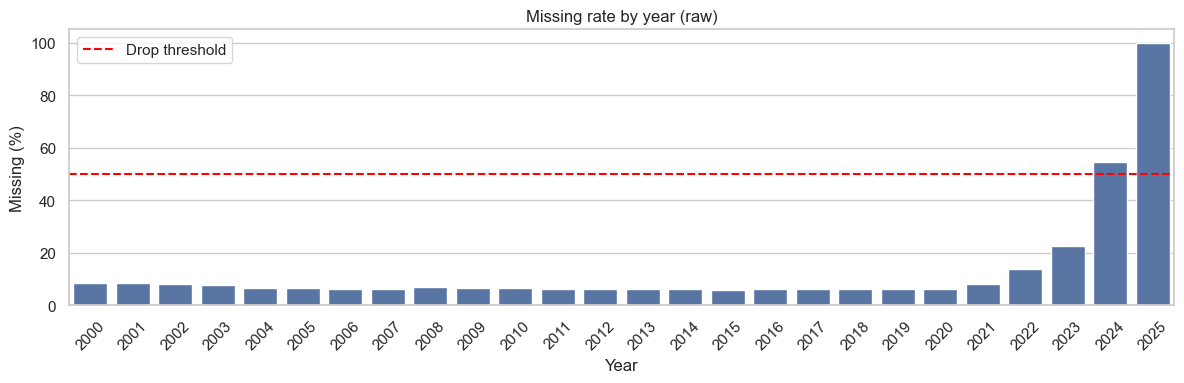

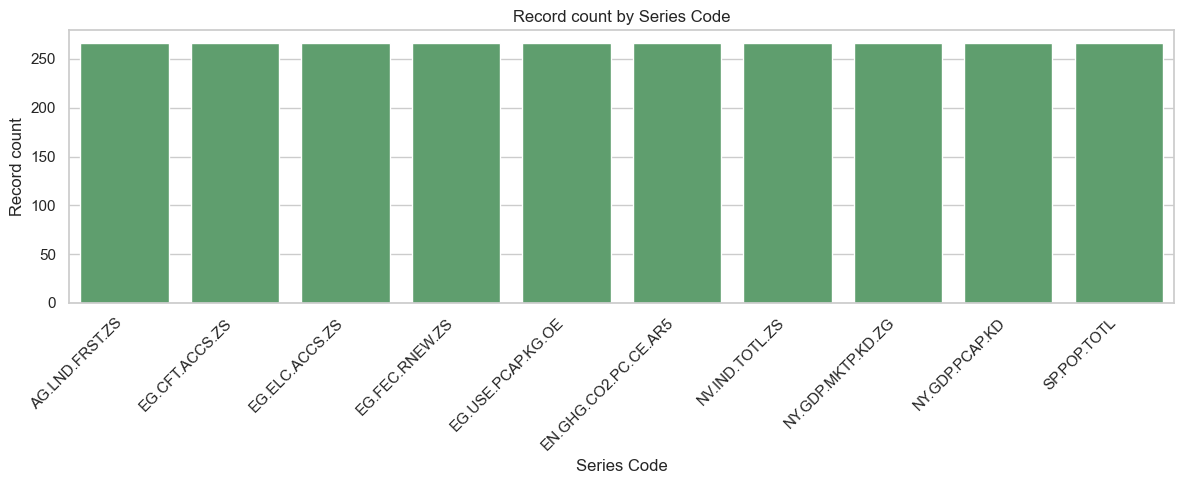

,Series Code,Series Name,record_count
0,AG.LND.FRST.ZS,Forest area (% of land area),266
1,EG.CFT.ACCS.ZS,Access to clean fuels and technologies for coo...,266
2,EG.ELC.ACCS.ZS,Access to electricity (% of population),266
3,EG.FEC.RNEW.ZS,Renewable energy consumption (% of total final...,266
4,EG.USE.PCAP.KG.OE,Energy use (kg of oil equivalent per capita),266
5,EN.GHG.CO2.PC.CE.AR5,Carbon dioxide (CO2) emissions excluding LULUC...,266
6,NV.IND.TOTL.ZS,"Industry (including construction), value added...",266
7,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),266
8,NY.GDP.PCAP.KD,GDP per capita (constant 2015 US$),266
9,SP.POP.TOTL,"Population, total",266


In [45]:
# Đối chiếu series với metadata
series_metadata = None
for enc in ["utf-8", "utf-8-sig", "cp1252", "latin-1"]:
    try:
        series_metadata = pd.read_csv(SERIES_METADATA_PATH, encoding=enc)
        break
    except Exception:
        continue
if series_metadata is None:
    raise RuntimeError("Không thể đọc Series-Metadata.csv với các encoding đã thử")

metadata_match_df = pd.DataFrame({
    "Series Code": series_target
})
metadata_match_df = metadata_match_df.merge(
    series_metadata[["Series Code", "Series Name"]].drop_duplicates(),
    on="Series Code",
    how="left"
 )
metadata_match_df["in_metadata"] = metadata_match_df["Series Name"].notna()

# Schema contract cho df_tidy
tidy_required_cols = ["Country Name", "Country Code", "Year"] + list(SERIES_CODES.values())
missing_tidy_cols = [c for c in tidy_required_cols if c not in df_tidy.columns]

numeric_target_cols = [c for c in SERIES_CODES.values() if c in df_tidy.columns]
numeric_dtype_ok = bool(df_tidy[numeric_target_cols].apply(pd.api.types.is_numeric_dtype).all()) if numeric_target_cols else False
year_dtype_ok = pd.api.types.is_integer_dtype(df_tidy["Year"]) if "Year" in df_tidy.columns else False
year_min_ok = int(df_tidy["Year"].min()) >= 2000 if "Year" in df_tidy.columns and len(df_tidy) else False
year_max_ok = int(df_tidy["Year"].max()) <= 2023 if "Year" in df_tidy.columns and len(df_tidy) else False
unique_key_ok = not df_tidy.duplicated(subset=["Country Code", "Year"]).any() if all(c in df_tidy.columns for c in ["Country Code", "Year"]) else False

tidy_contract_report = pd.DataFrame({
    "check": [
        "required_columns_present",
        "year_dtype_integer",
        "target_columns_numeric",
        "year_min_gte_2000",
        "year_max_lte_2023",
        "country_year_unique_key",
    ],
    "value": [
        len(missing_tidy_cols) == 0,
        year_dtype_ok,
        numeric_dtype_ok,
        year_min_ok,
        year_max_ok,
        unique_key_ok,
    ]
})

quality_metrics = {
    "raw_rows": int(len(df_raw)),
    "clean_rows": int(len(df_clean)),
    "target_series_count": int(df_stage1["Series Code"].nunique()),
    "analysis_year_min": int(analysis_year_min),
    "analysis_year_max": int(analysis_year_max),
    "dropped_years": drop_years,
    "long_rows": int(len(df_long)),
    "tidy_rows": int(len(df_tidy)),
    "tidy_cols": int(df_tidy.shape[1]),
    "series_in_metadata": int(metadata_match_df["in_metadata"].sum()),
}

print("Quality metrics Stage 2:")
display(pd.Series(quality_metrics, name="value").to_frame())

print("Series target vs metadata:")
display(metadata_match_df)

print("Tidy schema contract:")
display(tidy_contract_report)

# Biểu đồ 1: Missing % theo năm
plt.figure(figsize=(12, 4))
ax = sns.barplot(data=missing_year_df, x="year", y="missing_pct", color="#4C72B0")
ax.axhline(CONFIG["missing_year_drop_threshold_pct"], linestyle="--", color="red", label="Drop threshold")
ax.set_title("Missing rate by year (raw)")
ax.set_xlabel("Year")
ax.set_ylabel("Missing (%)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Biểu đồ 2: Số bản ghi theo series trong tập clean target
series_count_df = (
    df_stage1.groupby(["Series Code", "Series Name"]).size()
    .reset_index(name="record_count")
    .sort_values("record_count", ascending=False)
)

plt.figure(figsize=(12, 5))
sns.barplot(data=series_count_df, x="Series Code", y="record_count", color="#55A868")
plt.title("Record count by Series Code")
plt.xlabel("Series Code")
plt.ylabel("Record count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(series_count_df.head(10))

## 10. Lưu kết quả 
### Mục đích
Lưu trữ các đầu ra trung gian quan trọng để tái sử dụng ở các giai đoạn phân tích tiếp theo.

### Phương pháp
- Xuất bảng long sang `Data/processed_long.csv`.
- Xuất bảng tidy sang `Data/processed_tidy.csv`.

In [ ]:
processed_long_path = f"{CONFIG['output_dir']}/processed_long.csv"
processed_tidy_path = f"{CONFIG['output_dir']}/processed_tidy.csv"

df_long.to_csv(processed_long_path, index=False)
df_tidy.to_csv(processed_tidy_path, index=False)

print("Saved:")
print("-", processed_long_path)
print("-", processed_tidy_path)

Saved:
- Data/processed_long.csv
- Data/processed_tidy.csv


## Tổng kết giai đoạn tiền xử lí

Giai đoạn 1 đã hoàn thành phần mô tả cấu trúc và chất lượng dữ liệu thô. Giai đoạn 2 đã hoàn tất tiền xử lý gồm làm sạch bản ghi, chuẩn hóa missing, chốt scope 2000–2023, chuyển đổi wide -> long -> tidy, kiểm tra schema contract, đối chiếu metadata và lưu các artefact chuẩn `processed_long.csv`, `processed_tidy.csv`.

## 11. Giai đoạn 3 — Phân tích viễn cảnh đối với từng mục tiêu

Xác định rõ khung phân tích cho các mục tiêu cốt lõi nhằm bảo đảm cơ sở lựa chọn biến và khả năng trực quan hóa.

### 11.1. Mục tiêu 1 — Kiểm chứng đường cong *Kuznets* (GDP bình quân đầu người và thải CO2)

#### (1) Mục tiêu phân tích và trường dữ liệu trực quan hóa
- **Mục tiêu:** Kiểm tra liệu quan hệ giữa mức giàu có và phát thải CO2 bình quân đầu người có dạng **U ngược** hay không.
- **Trường dữ liệu chính:**
  - `NY.GDP.PCAP.KD` → `gdp_per_capita` (trục X)
  - `EN.GHG.CO2.PC.CE.AR5` → `co2_per_capita` (trục Y)
- **Trường dữ liệu hỗ trợ:**
  - `SP.POP.TOTL` → `population_total` (kích thước bubble)
  - `Year` (lọc theo phạm vi phân tích 2000–2023)

#### (2) Ý nghĩa các metrics
- **GDP per capita (constant 2015 US$):** đại diện mức phát triển kinh tế theo đầu người, đã cố định theo giá 2015 để giảm nhiễu lạm phát.
- **CO2 emissions per capita:** phản ánh lượng phát thải bình quân đầu người, phù hợp để so sánh giữa các quốc gia khác quy mô.
- **Population, total:** đại diện quy mô tác động tuyệt đối của quốc gia, dùng như trọng số trực quan.

#### (3) Vì sao metrics phù hợp với mục tiêu
- Cặp biến GDP/CO2 bình quân đầu người là bộ chỉ số kinh điển để kiểm định giả thuyết Kuznets môi trường.
- Việc chuẩn hóa theo đầu người giúp tránh sai lệch do quy mô dân số.
- Thêm trọng số dân số giúp biểu đồ phản ánh tốt hơn tầm ảnh hưởng toàn cầu của từng điểm dữ liệu.

#### (4) Mối quan hệ giữa các trường dữ liệu và lựa chọn trực quan
- Quan hệ kỳ vọng là **phi tuyến** (tăng rồi giảm), do đó hồi quy đa thức phù hợp hơn tuyến tính đơn.
- Cần kiểm soát ngoại lệ ở nhóm thu nhập rất cao hoặc quốc gia phụ thuộc nhiên liệu hóa thạch mạnh.
- Có thể cân nhắc kiểm tra độ nhạy khi dùng trục X theo log-scale để tránh cụm dồn ở vùng GDP thấp.

---

### 11.2. Mục tiêu 2 — Decoupling: tăng trưởng kinh tế và chuyển dịch năng lượng xanh

#### (1) Mục tiêu phân tích và trường dữ liệu trực quan hóa
- **Mục tiêu:** Xác định quốc gia/nhóm quốc gia có thể duy trì tăng trưởng GDP trong khi tăng tỷ trọng năng lượng tái tạo và giảm CO2 hay không.
- **Trường dữ liệu chính:**
  - `EG.FEC.RNEW.ZS` → `renewable_energy_percent`
  - `EN.GHG.CO2.PC.CE.AR5` → `co2_per_capita`
- **Trường dữ liệu hỗ trợ:**
  - `NY.GDP.MKTP.KD.ZG` → `gdp_growth`
  - `IncomeGroup` (so sánh nhóm High income và Lower middle income khi có mapping); Có nên dùng cả 4 nhóm High, Upper middle, Lower middle, Low không? --> Không vì ở phần kiểm chứng, phân tích chính vẫn nên giữ 2 nhóm để narrative mạnh và sạch.
  - `Year` (ưu tiên 20 năm gần nhất trong scope hợp lệ)

#### (2) Ý nghĩa các metrics
- **GDP growth (annual %):** đo động lực tăng trưởng ngắn hạn của nền kinh tế.
- **Renewable energy consumption (%):** đo mức độ chuyển đổi cơ cấu năng lượng sang nguồn tái tạo.
- **CO2 emissions per capita:** đo kết quả môi trường đầu ra của quá trình tăng trưởng và tiêu dùng năng lượng.

#### (3) Vì sao metrics phù hợp với mục tiêu
- Ba chỉ số tạo thành chuỗi logic **động lực kinh tế → chuyển đổi năng lượng → kết quả phát thải**.
- Nếu chỉ nhìn GDP và CO2 sẽ khó xác định vai trò của chuyển dịch năng lượng; bổ sung Renewable giúp giải thích cơ chế.
- So sánh theo IncomeGroup cho phép nhận diện khác biệt năng lực chuyển đổi giữa các nhóm phát triển.

#### (4) Mối quan hệ giữa các trường dữ liệu và lựa chọn trực quan
- Tín hiệu decoupling mạnh khi: Renewable tăng ổn định, CO2 giảm theo xu hướng, GDP growth vẫn duy trì dương trong trung hạn.
- Dữ liệu chuỗi thời gian phù hợp với line chart để phát hiện độ trễ chính sách và điểm bẻ xu hướng.
- Do khác đơn vị đo, tách trục trái/phải là cần thiết để tránh bóp méo mức biến động tương đối.

---

### 11.3. Mục tiêu 3 — Cái giá của công nghiệp hóa: hệ sinh thái và chất lượng sống

#### (1) Mục tiêu phân tích và trường dữ liệu trực quan hóa
- **Mục tiêu:** Đánh giá liệu gia tăng công nghiệp hóa có đi kèm suy giảm tài nguyên sinh thái và chất lượng sống năng lượng hộ gia đình hay không.
- **Trường dữ liệu chính:**
  - `NV.IND.TOTL.ZS` → `industry_value_added_percent_gdp`
  - `AG.LND.FRST.ZS` → `forest_area_percent`
- **Trường dữ liệu hỗ trợ:**
  - `EG.CFT.ACCS.ZS` → `access_clean_fuels`
  - `Year` (2000–2023)

#### (2) Ý nghĩa các metrics
- **Industry value added (% GDP):** phản ánh mức độ công nghiệp hóa trong cơ cấu kinh tế.
- **Forest area (% land area):** phản ánh trạng thái “vốn tự nhiên” của hệ sinh thái.
- **Access to clean fuels for cooking (% population):** phản ánh chất lượng sống cơ bản và mức độ giảm phơi nhiễm ô nhiễm không khí trong hộ gia đình.

#### (3) Vì sao metrics phù hợp với mục tiêu
- Bộ chỉ số bao phủ đồng thời **kinh tế cấu trúc** (industry), **sinh thái** (forest) và **phúc lợi dân sinh** (clean cooking).
- Đây là cách tiếp cận đa chiều để tránh kết luận thiên lệch khi chỉ nhìn một chỉ số môi trường.
- Các biến đều ở dạng tỷ lệ phần trăm nên thuận lợi cho so sánh xuyên quốc gia.

#### (4) Mối quan hệ giữa các trường dữ liệu và lựa chọn trực quan
- Heatmap giúp lượng hóa cường độ tương quan (ví dụ tương quan nghịch giữa industry và forest).
- Hexbin giúp quan sát vùng mật độ cao của dữ liệu country-year, giảm nhiễu chồng điểm so với scatter thường.
- Kết luận cần phân biệt rõ: **tương quan không đồng nghĩa nhân quả**; kết quả chỉ thể hiện xu hướng liên hệ thống kê.

---

### 11.4. Ma trận lựa chọn biến và nguyên tắc đọc kết quả

| Mục tiêu | Biến cốt lõi | Biến hỗ trợ | Quan hệ kỳ vọng | Trực quan hóa chính |
|---|---|---|---|---|
| Kuznets | `gdp_per_capita`, `co2_per_capita` | `population_total`, `Year` | Phi tuyến U ngược | Bubble Scatter + Polynomial Trend |
| Decoupling | `renewable_energy_percent`, `co2_per_capita` | `gdp_growth`, `IncomeGroup`, `Year` | Tách rời tăng trưởng–phát thải | Dual-axis Line |
| Công nghiệp hóa | `industry_value_added_percent_gdp`, `forest_area_percent` | `access_clean_fuels`, `Year` | Tương quan đa chiều | Heatmap + Hexbin |

**Nguyên tắc diễn giải chung**
- Luôn nêu rõ giới hạn dữ liệu thiếu và ảnh hưởng của ngoại lệ.
- Không suy diễn nhân quả khi chưa có mô hình kiểm định nhân quả chuyên biệt.

## 12. Lựa chọn biểu đồ và triển khai trực quan hóa cho từng mục tiêu phân tích
- Chọn biểu đồ theo đúng bản chất dữ liệu (*numerical, categorical, time-series*).
- Mỗi hình có tiêu đề, đơn vị, phạm vi năm và số quan sát hợp lệ để đảm bảo diễn giải minh bạch.
- Tránh biểu diễn gây hiểu nhầm (không so sánh sai đơn vị, không suy diễn nhân quả từ tương quan).

**Nguồn dữ liệu bắt buộc cho Mục 12:**
- `Data/processed_tidy.csv` (dữ liệu chính để phân tích đa biến theo country-year).
- `Data/processed_long.csv` (dữ liệu kiểm tra/đối chiếu cấu trúc long nếu cần).

Phạm vi trực quan hóa: **2000–2023**.

In [19]:
# Chuẩn bị dữ liệu cho giai đoạn trực quan hóa mục tiêu phân tích
tidy_candidates = [
    "Data/processed_tidy.csv",
    "../Data/processed_tidy.csv",
]
long_candidates = [
    "Data/processed_long.csv",
    "../Data/processed_long.csv",
]

def _read_first_available(paths, name):
    last_err = None
    for p in paths:
        try:
            return pd.read_csv(p, encoding="utf-8")
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Không đọc được {name} từ các path: {paths}. Lỗi cuối: {last_err}")

df_tidy_src = _read_first_available(tidy_candidates, "processed_tidy.csv")
df_long_src = _read_first_available(long_candidates, "processed_long.csv")

analysis_df = df_tidy_src.copy()

if "Year" not in analysis_df.columns:
    raise ValueError("processed_tidy.csv thiếu cột Year")

analysis_df["Year"] = pd.to_numeric(analysis_df["Year"], errors="coerce")
analysis_df = analysis_df.dropna(subset=["Year"]).copy()
analysis_df["Year"] = analysis_df["Year"].astype(int)
analysis_df = analysis_df[(analysis_df["Year"] >= 2000) & (analysis_df["Year"] <= 2023)].copy()

metric_cols = [
    "gdp_per_capita",
    "co2_per_capita",
    "population_total",
    "renewable_energy_percent",
    "gdp_growth",
    "industry_value_added_percent_gdp",
    "forest_area_percent",
    "access_clean_fuels",
]
for c in metric_cols:
    if c in analysis_df.columns:
        analysis_df[c] = pd.to_numeric(analysis_df[c], errors="coerce")

# Tạo nhóm thu nhập xấp xỉ từ GDP per capita để phục vụ so sánh categorical × numerical
analysis_df["IncomeGroupProxy"] = "Unknown"
if "gdp_per_capita" in analysis_df.columns and analysis_df["gdp_per_capita"].notna().sum() >= 100:
    valid_idx = analysis_df["gdp_per_capita"].dropna().index
    base_labels = ["Low", "Lower middle", "Upper middle", "High"]

    try:
        qcat = pd.qcut(analysis_df.loc[valid_idx, "gdp_per_capita"], q=4, duplicates="drop")
        n_bins = int(qcat.cat.categories.size)
        labels = base_labels[:n_bins]

        code_series = pd.Series(qcat.cat.codes, index=valid_idx)
        mapped_labels = code_series.map(lambda i: labels[int(i)] if i >= 0 else "Unknown")
        analysis_df.loc[valid_idx, "IncomeGroupProxy"] = mapped_labels.values
    except Exception:
        analysis_df["IncomeGroupProxy"] = "Unknown"

print("Data source for Section 12:")
print("- processed_tidy.csv rows:", len(df_tidy_src))
print("- processed_long.csv rows:", len(df_long_src))
print("Analysis scope years: 2000-2023")
print(f"Rows in analysis_df: {len(analysis_df):,}")
print("IncomeGroupProxy distribution:")
display(analysis_df["IncomeGroupProxy"].value_counts(dropna=False).to_frame("n"))

Data source for Section 12:
- processed_tidy.csv rows: 6360
- processed_long.csv rows: 58932
Analysis scope years: 2000-2023
Rows in analysis_df: 6,360
IncomeGroupProxy distribution:


,n
IncomeGroupProxy,
Low,1528
Lower middle,1528
High,1528
Upper middle,1527
Unknown,249


### 12.1. Mục tiêu 1 — Kiểm chứng Kuznets (`gdp_per_capita` × `co2_per_capita`)

**Lựa chọn biểu đồ**
- **Scatter/Bubble + Hexbin** cho cặp numerical × numerical để vừa nhìn ngoại lệ, vừa đọc mật độ khi điểm dày.
- **Line chart theo năm (2 subplot)** để kiểm tra động học thời gian của từng biến, tránh gộp hai đơn vị khác nhau vào cùng trục.

**Vì sao phù hợp**
- Quan hệ Kuznets kỳ vọng **phi tuyến** nên scatter/hexbin phù hợp hơn bar chart.
- Dân số được dùng làm kích thước điểm trong bubble để phản ánh trọng số quy mô quốc gia.
- Với GDP lệch phải, dùng trục X log giúp giảm chồng điểm và tránh hiểu sai xu hướng.

**Lưu ý tránh hiểu nhầm**
- Đường xu hướng bậc 2 chỉ là mô tả tương quan, không kết luận nhân quả.
- Báo cáo luôn nêu số quan sát hợp lệ `n` và phạm vi năm 2000–2023.

Kuznets sample size (n): 5,865


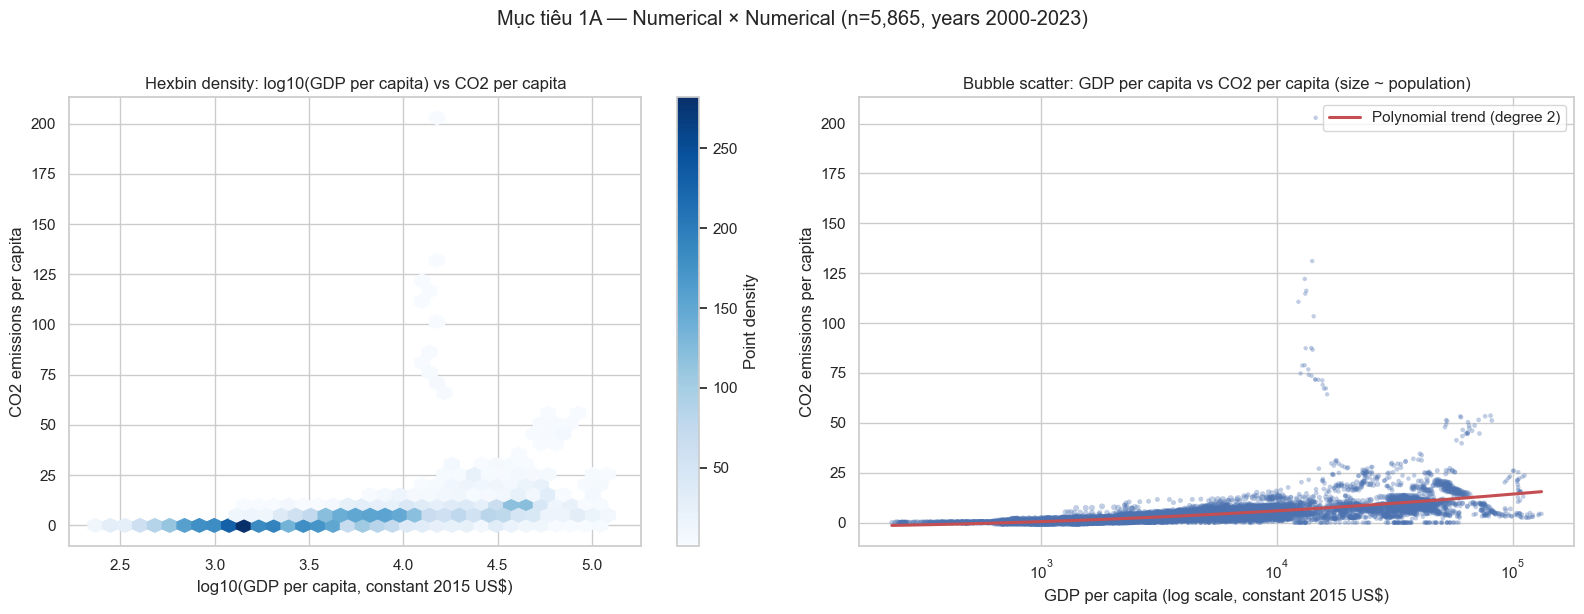

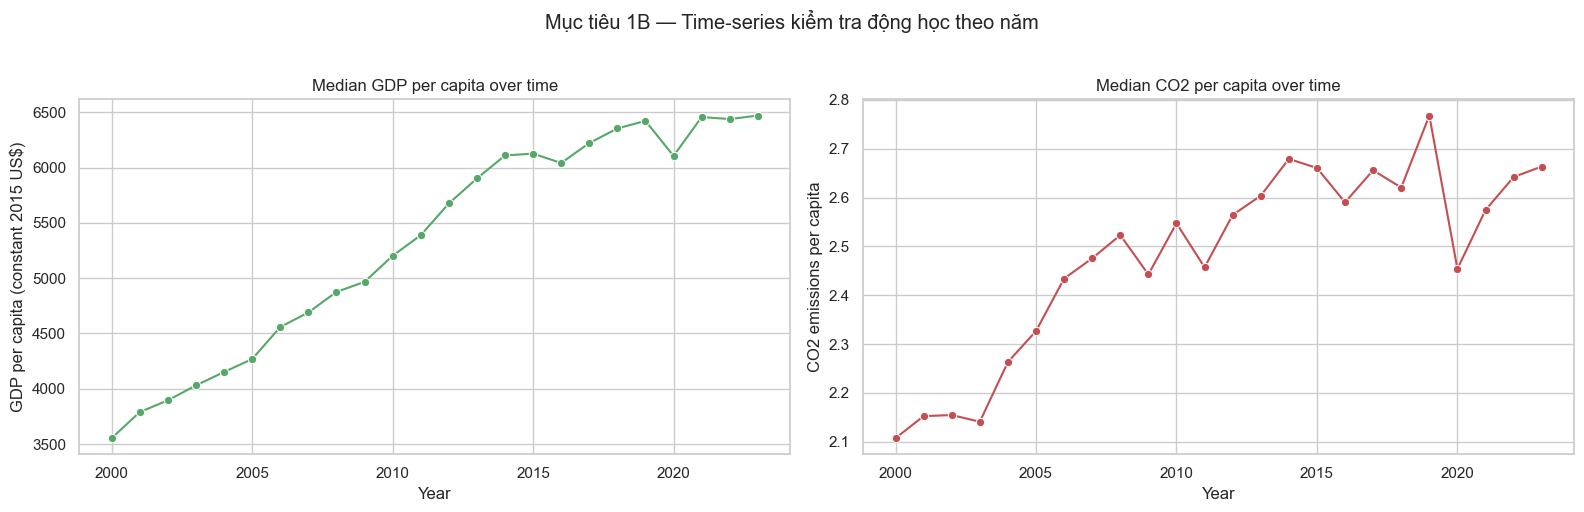

In [24]:
# Mục tiêu 1A: Scatter/Bubble + Hexbin cho GDP per capita vs CO2 per capita
df_kuznets = analysis_df[["Year", "gdp_per_capita", "co2_per_capita", "population_total"]].dropna().copy()
n_k = len(df_kuznets)
print(f"Kuznets sample size (n): {n_k:,}")

year_min = int(df_kuznets["Year"].min()) if n_k > 0 else 2000
year_max = int(df_kuznets["Year"].max()) if n_k > 0 else 2023

if n_k > 0:
    pop_size = np.sqrt(df_kuznets["population_total"].clip(lower=1))
    df_kuznets["bubble_size"] = 10 + 80 * (pop_size - pop_size.min()) / (pop_size.max() - pop_size.min() + 1e-9)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    hb = axes[0].hexbin(
        x=np.log10(df_kuznets["gdp_per_capita"].clip(lower=1)),
        y=df_kuznets["co2_per_capita"],
        gridsize=35,
        cmap="Blues",
        mincnt=1,
    )
    cb = fig.colorbar(hb, ax=axes[0])
    cb.set_label("Point density")
    axes[0].set_title("Hexbin density: log10(GDP per capita) vs CO2 per capita")
    axes[0].set_xlabel("log10(GDP per capita, constant 2015 US$)")
    axes[0].set_ylabel("CO2 emissions per capita")

    sns.scatterplot(
        data=df_kuznets,
        x="gdp_per_capita",
        y="co2_per_capita",
        size="bubble_size",
        sizes=(10, 120),
        alpha=0.35,
        linewidth=0,
        legend=False,
        color="#4C72B0",
        ax=axes[1],
    )
    axes[1].set_xscale("log")
    axes[1].set_title("Bubble scatter: GDP per capita vs CO2 per capita (size ~ population)")
    axes[1].set_xlabel("GDP per capita (log scale, constant 2015 US$)")
    axes[1].set_ylabel("CO2 emissions per capita")

    x = np.log10(df_kuznets["gdp_per_capita"].clip(lower=1).values)
    y = df_kuznets["co2_per_capita"].values

    if len(np.unique(x)) >= 3:
        coef = np.polyfit(x, y, deg=2)
        x_fit = np.linspace(x.min(), x.max(), 200)
        y_fit = np.polyval(coef, x_fit)
        axes[1].plot(10 ** x_fit, y_fit, color="#C44E52", linewidth=2.2, label="Polynomial trend (degree 2)")
        axes[1].legend()

    plt.suptitle(f"Mục tiêu 1A — Numerical × Numerical (n={n_k:,}, years {year_min}-{year_max})", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Không đủ dữ liệu hợp lệ cho biểu đồ Mục tiêu 1A.")

# Mục tiêu 1B: Time-series (2 subplot riêng đơn vị)
df_kuznets_year = (
    analysis_df.groupby("Year", as_index=False)[["gdp_per_capita", "co2_per_capita"]]
    .median()
    .dropna(subset=["gdp_per_capita", "co2_per_capita"], how="all")
)

if len(df_kuznets_year) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

    sns.lineplot(data=df_kuznets_year, x="Year", y="gdp_per_capita", marker="o", color="#55A868", ax=axes[0])
    axes[0].set_title("Median GDP per capita over time")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("GDP per capita (constant 2015 US$)")

    sns.lineplot(data=df_kuznets_year, x="Year", y="co2_per_capita", marker="o", color="#C44E52", ax=axes[1])
    axes[1].set_title("Median CO2 per capita over time")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("CO2 emissions per capita")

    plt.suptitle("Mục tiêu 1B — Time-series kiểm tra động học theo năm", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Không đủ dữ liệu theo năm cho biểu đồ Mục tiêu 1B.")

#### Insight phân tích (Mục tiêu 1A — GDP per capita vs CO2 per capita)
- **Observation:** CO2 per capita có xu hướng tăng theo GDP per capita (trên trục log), đồng thời xuất hiện nhóm phát thải rất cao ở đuôi phải.
- **Evidence:** Trung vị GDP per capita = **5,134 USD**; trung vị CO2 per capita = **2.49**; tương quan Pearson giữa log10(GDP per capita) và CO2 per capita = **0.462**; nhóm top 5% phát thải chiếm khoảng **5.0%** quan sát.
- **Interpretation:** Tăng trưởng thu nhập đi kèm gia tăng phát thải ở mức quan sát toàn cục; tuy nhiên phân tán điểm lớn cho thấy khác biệt cấu trúc năng lượng giữa các quốc gia.
- **Implication:** Chính sách tăng trưởng cần song hành với giảm cường độ carbon (hiệu quả năng lượng, tiêu chuẩn công nghệ sạch, mở rộng renewable) để tránh khóa cứng quỹ đạo phát thải cao.
- **Limitation:** Đây là liên hệ tương quan tại mức country-year, chưa chứng minh nhân quả; outlier phát thải cao có thể ảnh hưởng mạnh đến xu hướng tổng quát.

#### Insight phân tích (Mục tiêu 1B — Time-series GDP và CO2 trung vị)
- **Observation:** Cả GDP per capita trung vị và CO2 per capita trung vị cùng tăng theo thời gian, nhưng tốc độ tăng GDP lớn hơn rõ rệt.
- **Evidence:** GDP trung vị tăng từ **3,553** lên **6,471 USD** (**+82.1%**); CO2 trung vị tăng từ **2.11** lên **2.66** (**+26.4%**); biên độ CO2 trung vị theo năm là **2.11–2.77**.
- **Interpretation:** Nền kinh tế toàn mẫu mở rộng nhanh hơn mức tăng phát thải bình quân đầu người, gợi ý dấu hiệu cải thiện tương đối về hiệu suất phát thải.
- **Implication:** Cần tiếp tục duy trì tăng trưởng gắn với đổi mới công nghệ và tái cấu trúc năng lượng để củng cố xu hướng “tăng trưởng nhanh hơn phát thải”.
- **Limitation:** Số liệu trung vị làm mượt biến động và có thể che khuất các cú sốc theo khu vực/quốc gia; độ trễ cập nhật dữ liệu cuối kỳ có thể làm sai lệch mức tăng ngắn hạn.

### 12.2. Mục tiêu 2 — Decoupling tăng trưởng, năng lượng tái tạo và phát thải

**Lựa chọn biểu đồ**
- **Scatter** cho cặp `renewable_energy_percent` × `co2_per_capita` để nhìn liên hệ quan sát tại mức country-year.
- **Scatter có phân nhóm + đường tham chiếu tăng trưởng 0%** cho `gdp_growth` × `co2_per_capita` nhằm nhận diện vùng decoupling.
- **Line chart theo nhóm thu nhập (proxy)** để xem quỹ đạo theo thời gian.
- **Boxplot** cho categorical × numerical để so sánh phân phối giữa các nhóm thay vì chỉ dùng trung bình.

**Vì sao phù hợp**
- Decoupling cần đồng thời góc nhìn *cross-sectional* và *time-series*; một loại biểu đồ đơn lẻ là chưa đủ.
- Boxplot thể hiện median/IQR/outlier giúp đánh giá ổn định phân phối theo nhóm.

**Lưu ý:** Group thu nhập ở đây là **IncomeGroupProxy** suy ra từ phân vị GDP per capita (không phải nhãn chính thức của WB).

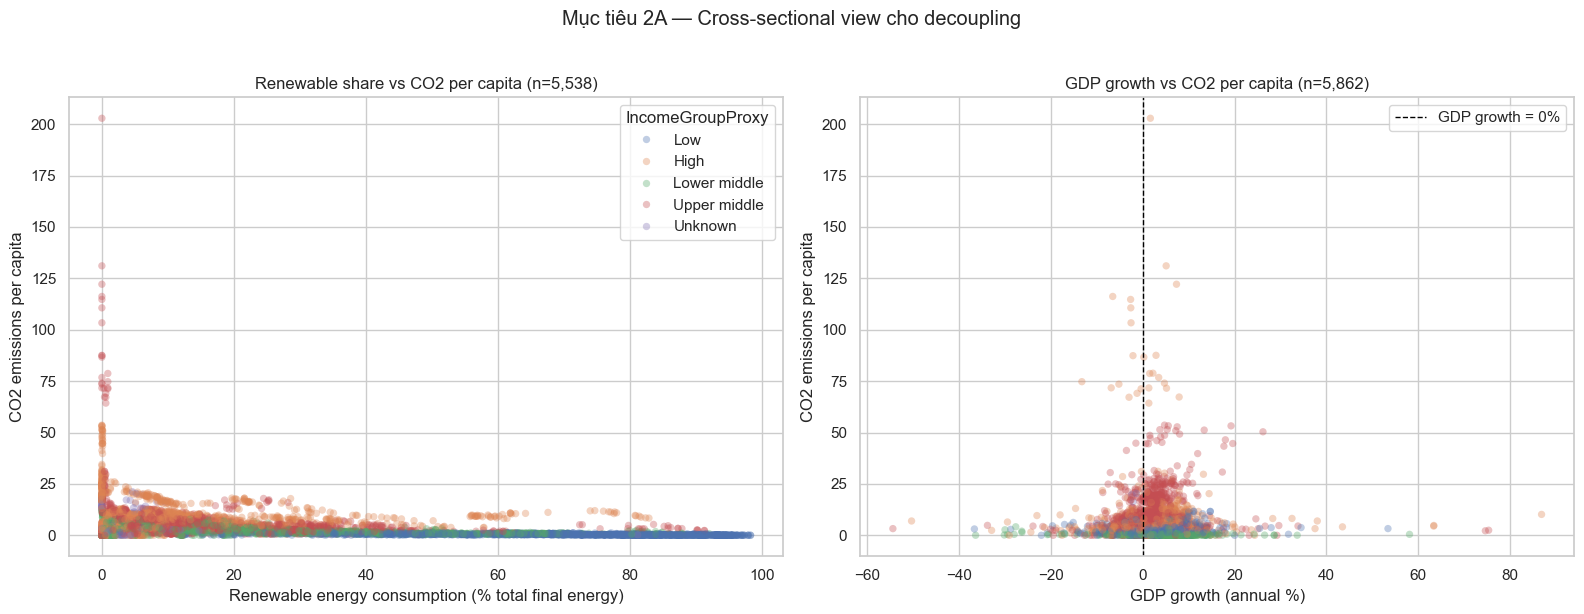

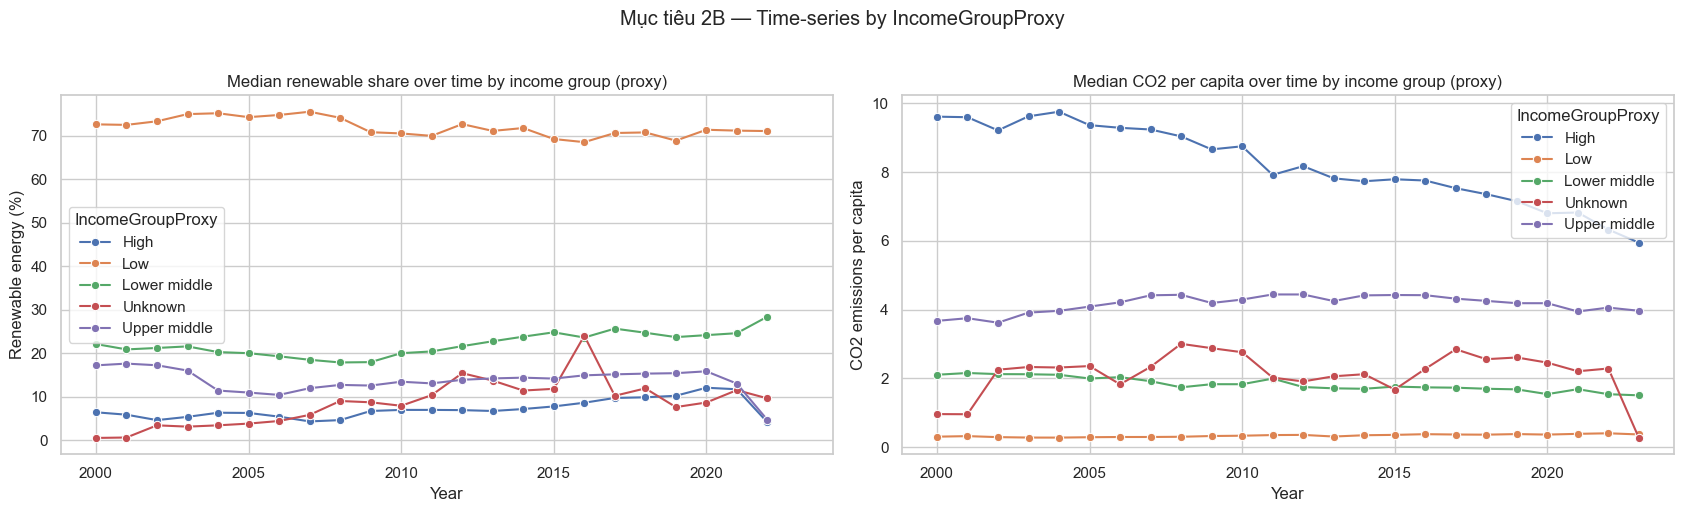

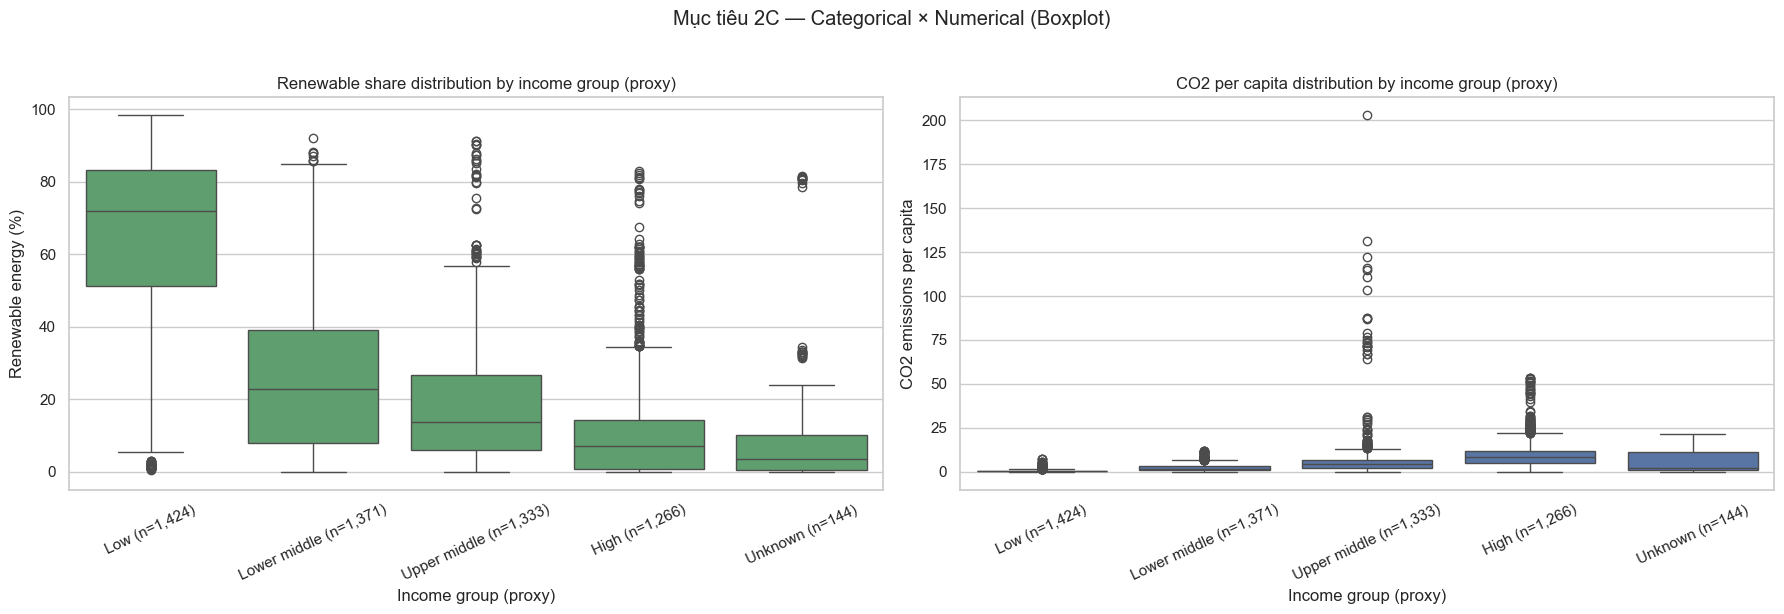

In [25]:
# Mục tiêu 2A: Renewable vs CO2 (scatter) và GDP growth vs CO2 (scatter theo nhóm)
df_decouple_a = analysis_df[["renewable_energy_percent", "co2_per_capita", "IncomeGroupProxy"]].dropna().copy()
df_decouple_b = analysis_df[["gdp_growth", "co2_per_capita", "IncomeGroupProxy"]].dropna().copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if len(df_decouple_a) > 0:
    sns.scatterplot(
        data=df_decouple_a.sample(min(len(df_decouple_a), 12000), random_state=42),
        x="renewable_energy_percent",
        y="co2_per_capita",
        hue="IncomeGroupProxy",
        alpha=0.35,
        s=28,
        linewidth=0,
        ax=axes[0],
    )
    axes[0].set_title(f"Renewable share vs CO2 per capita (n={len(df_decouple_a):,})")
    axes[0].set_xlabel("Renewable energy consumption (% total final energy)")
    axes[0].set_ylabel("CO2 emissions per capita")
else:
    axes[0].text(0.5, 0.5, "No valid data", ha="center", va="center")
    axes[0].set_title("Renewable share vs CO2 per capita")

if len(df_decouple_b) > 0:
    sns.scatterplot(
        data=df_decouple_b.sample(min(len(df_decouple_b), 12000), random_state=42),
        x="gdp_growth",
        y="co2_per_capita",
        hue="IncomeGroupProxy",
        alpha=0.35,
        s=28,
        linewidth=0,
        legend=False,
        ax=axes[1],
    )
    axes[1].axvline(0, linestyle="--", color="black", linewidth=1, label="GDP growth = 0%")
    axes[1].set_title(f"GDP growth vs CO2 per capita (n={len(df_decouple_b):,})")
    axes[1].set_xlabel("GDP growth (annual %)")
    axes[1].set_ylabel("CO2 emissions per capita")
    axes[1].legend(loc="upper right")
else:
    axes[1].text(0.5, 0.5, "No valid data", ha="center", va="center")
    axes[1].set_title("GDP growth vs CO2 per capita")

plt.suptitle("Mục tiêu 2A — Cross-sectional view cho decoupling", y=1.02)
plt.tight_layout()
plt.show()

# Mục tiêu 2B: Time-series theo nhóm thu nhập (proxy), mỗi biến một panel
ts_cols = ["Year", "IncomeGroupProxy", "renewable_energy_percent", "co2_per_capita"]
df_decouple_ts = analysis_df[ts_cols].dropna(subset=["Year", "IncomeGroupProxy"]).copy()
df_decouple_ts = (
    df_decouple_ts.groupby(["Year", "IncomeGroupProxy"], as_index=False)[["renewable_energy_percent", "co2_per_capita"]]
    .median()
    .sort_values(["IncomeGroupProxy", "Year"])
)

if len(df_decouple_ts) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(17, 5), sharex=True)
    sns.lineplot(
        data=df_decouple_ts,
        x="Year",
        y="renewable_energy_percent",
        hue="IncomeGroupProxy",
        marker="o",
        ax=axes[0],
    )
    axes[0].set_title("Median renewable share over time by income group (proxy)")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Renewable energy (%)")

    sns.lineplot(
        data=df_decouple_ts,
        x="Year",
        y="co2_per_capita",
        hue="IncomeGroupProxy",
        marker="o",
        ax=axes[1],
    )
    axes[1].set_title("Median CO2 per capita over time by income group (proxy)")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("CO2 emissions per capita")

    plt.suptitle("Mục tiêu 2B — Time-series by IncomeGroupProxy", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Không đủ dữ liệu cho biểu đồ time-series Mục tiêu 2B.")

# Mục tiêu 2C: Categorical × Numerical bằng boxplot (phân phối theo nhóm)
box_df = analysis_df[["IncomeGroupProxy", "renewable_energy_percent", "co2_per_capita"]].dropna().copy()
if len(box_df) > 0:
    group_order = ["Low", "Lower middle", "Upper middle", "High", "Unknown"]
    group_order = [g for g in group_order if g in box_df["IncomeGroupProxy"].unique()]
    counts = box_df["IncomeGroupProxy"].value_counts()
    label_map = {g: f"{g} (n={int(counts[g]):,})" for g in group_order if g in counts.index}
    box_df["IncomeGroupDisplay"] = box_df["IncomeGroupProxy"].map(label_map)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.boxplot(
        data=box_df,
        x="IncomeGroupDisplay",
        y="renewable_energy_percent",
        order=[label_map[g] for g in group_order if g in label_map],
        color="#55A868",
        ax=axes[0],
    )
    axes[0].set_title("Renewable share distribution by income group (proxy)")
    axes[0].set_xlabel("Income group (proxy)")
    axes[0].set_ylabel("Renewable energy (%)")
    axes[0].tick_params(axis="x", rotation=25)

    sns.boxplot(
        data=box_df,
        x="IncomeGroupDisplay",
        y="co2_per_capita",
        order=[label_map[g] for g in group_order if g in label_map],
        color="#4C72B0",
        ax=axes[1],
    )
    axes[1].set_title("CO2 per capita distribution by income group (proxy)")
    axes[1].set_xlabel("Income group (proxy)")
    axes[1].set_ylabel("CO2 emissions per capita")
    axes[1].tick_params(axis="x", rotation=25)

    plt.suptitle("Mục tiêu 2C — Categorical × Numerical (Boxplot)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Không đủ dữ liệu cho boxplot Mục tiêu 2C.")

#### Insight phân tích (Mục tiêu 2A — Renewable/GDP growth và CO2)
- **Observation:** Tỷ trọng năng lượng tái tạo cao hơn thường đi kèm CO2 per capita thấp hơn; đa số quan sát có tăng trưởng GDP dương.
- **Evidence:** Tương quan Renewable–CO2 = **-0.373**; tỷ lệ quan sát có GDP growth dương = **85.4%**; trong nhóm GDP growth dương, CO2 trung vị = **2.48**.
- **Interpretation:** Có tín hiệu decoupling tương đối: tăng trưởng vẫn diễn ra trong khi quan hệ giữa mở rộng renewable và phát thải mang chiều âm.
- **Implication:** Ưu tiên mở rộng renewable trong các nền kinh tế tăng trưởng nhanh có thể giảm áp lực phát thải mà không làm gián đoạn động lực tăng trưởng.
- **Limitation:** Scatter vẫn có độ phân tán lớn, cho thấy còn nhiều biến nền (cấu trúc ngành, chính sách, công nghệ) chưa được kiểm soát.

#### Insight phân tích (Mục tiêu 2B — Time-series theo IncomeGroupProxy)
- **Observation:** Quỹ đạo renewable và CO2 khác nhau rõ theo nhóm thu nhập proxy, phản ánh mức độ chuyển dịch năng lượng không đồng đều.
- **Evidence:** Năm mới nhất của chuỗi là **2023**; tại năm này còn thiếu dữ liệu đồng thời cho cả hai chỉ số ở một số nhóm.
- **Interpretation:** So sánh xếp hạng nhóm tại điểm cuối chuỗi có rủi ro không ổn định; xu hướng dài hạn đáng tin cậy hơn so với kết luận từ một năm đơn lẻ.
- **Implication:** Đánh giá chính sách nên ưu tiên theo dõi quỹ đạo nhiều năm và dùng cửa sổ năm có đủ dữ liệu thay vì chỉ bám năm cuối.
- **Limitation:** Phân nhóm thu nhập sử dụng **IncomeGroupProxy** (từ phân vị GDP per capita), không phải phân loại chuẩn chính thức của World Bank.

#### Insight phân tích (Mục tiêu 2C — Boxplot theo nhóm thu nhập proxy)
- **Observation:** Phân phối renewable và CO2 khác biệt rõ giữa các nhóm; nhóm **Low** nổi bật với renewable cao và CO2 thấp theo trung vị.
- **Evidence:** Nhóm renewable trung vị cao nhất: **Low (71.95%)**; nhóm CO2 trung vị thấp nhất: **Low (0.32)**; chênh lệch median CO2 giữa nhóm cao nhất và thấp nhất là **8.15**.
- **Interpretation:** Khác biệt cấu trúc năng lượng giữa nhóm thu nhập có vai trò lớn trong mức phát thải bình quân, không chỉ phụ thuộc tốc độ tăng trưởng.
- **Implication:** Thiết kế lộ trình chuyển dịch cần phân nhóm chính sách theo đặc điểm thu nhập/cấu trúc năng lượng thay vì áp một công thức chung.
- **Limitation:** Boxplot nhạy với outlier và độ rộng mẫu nhóm; nhóm có số quan sát ít có thể làm trung vị và IQR kém ổn định.

### 12.3. Mục tiêu 3 — Công nghiệp hóa, hệ sinh thái và chất lượng sống

**Lựa chọn biểu đồ**
- **Hexbin** cho `industry_value_added_percent_gdp` × `forest_area_percent` để giảm chồng điểm và thể hiện mật độ quan sát.
- **Line chart median theo năm** (2 subplot) để đọc xu hướng cấu trúc qua thời gian.
- **Scatter + giới hạn trục y [0,100]** cho `industry_value_added_percent_gdp` × `access_clean_fuels` vì biến tiếp cận nhiên liệu sạch là tỷ lệ phần trăm có trần tự nhiên.
- **Heatmap tương quan** để tổng hợp quan hệ đa biến giữa industry, forest, clean fuels.

**Vì sao phù hợp**
- Mục tiêu 3 là bài toán đa chiều; kết hợp biểu đồ mật độ + xu hướng + tương quan giúp diễn giải cân bằng hơn.
- Heatmap phù hợp để tóm tắt cường độ liên hệ, sau đó dùng biểu đồ phân tán để kiểm tra hình thái quan hệ thực tế.

**Lưu ý tránh hiểu nhầm**
- Tương quan chỉ cho thấy mức liên hệ thống kê, không khẳng định chiều nhân quả.
- Kết luận luôn đi kèm giới hạn dữ liệu thiếu và khác biệt cấu trúc giữa các nhóm quốc gia.

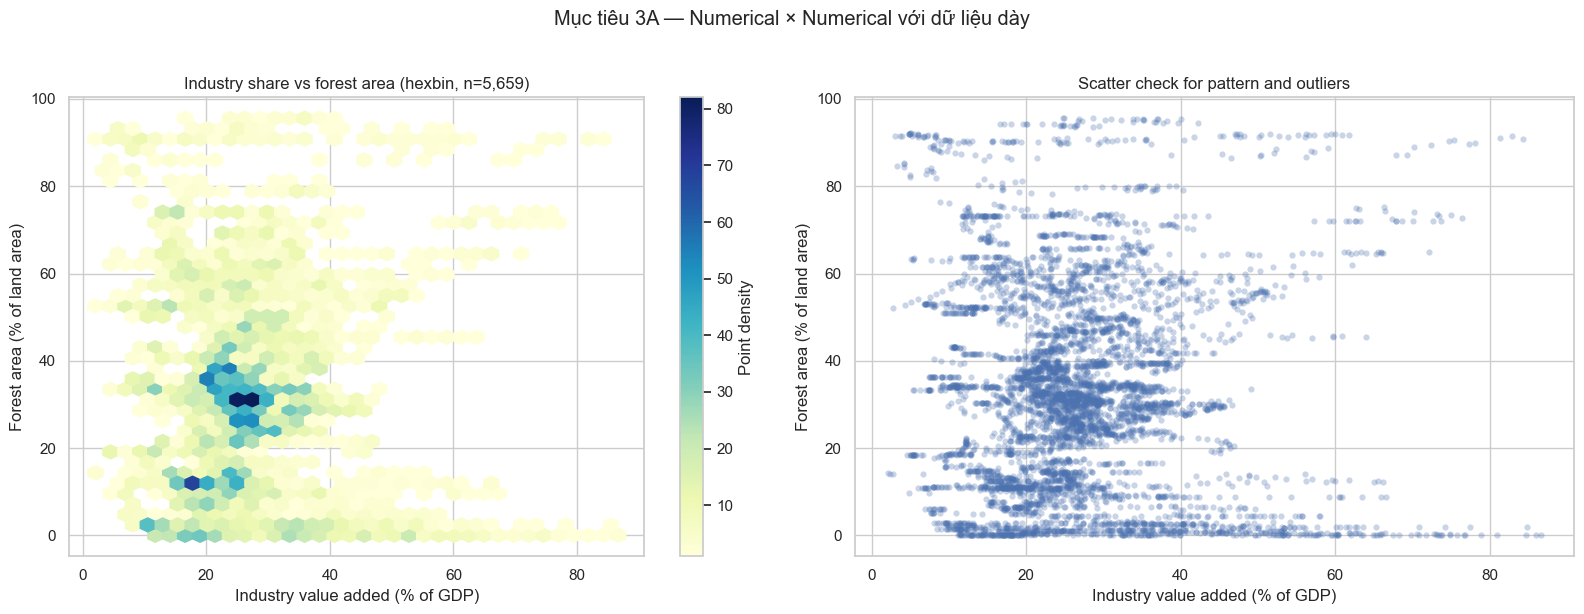

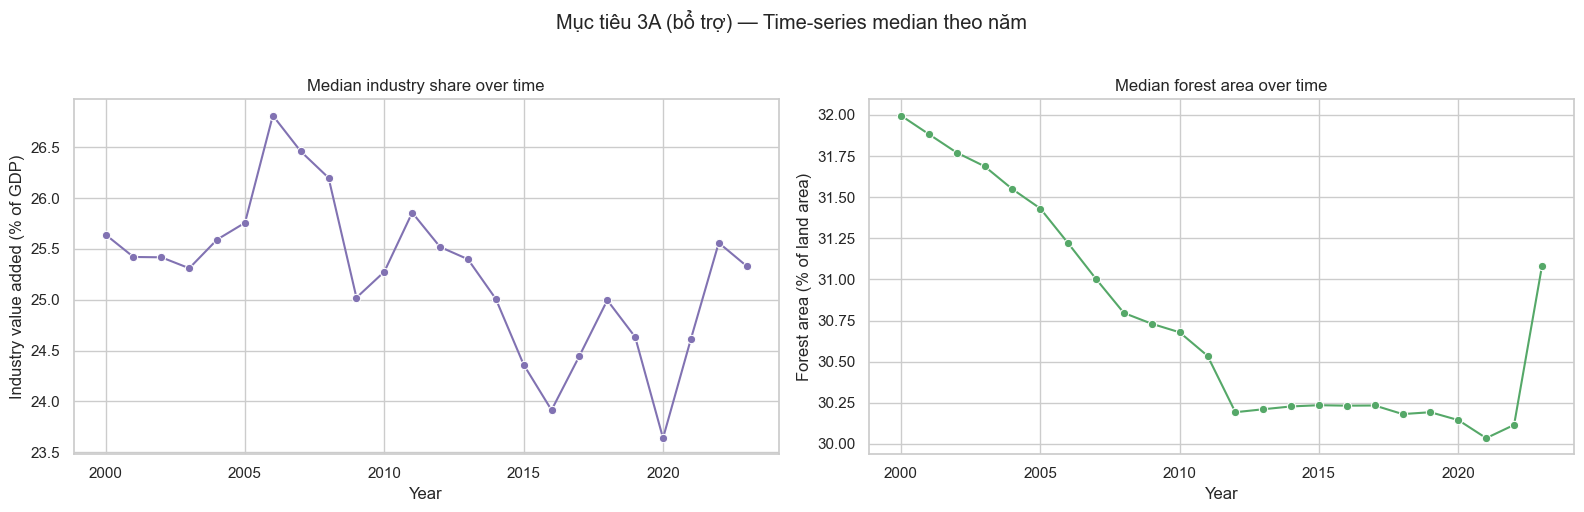

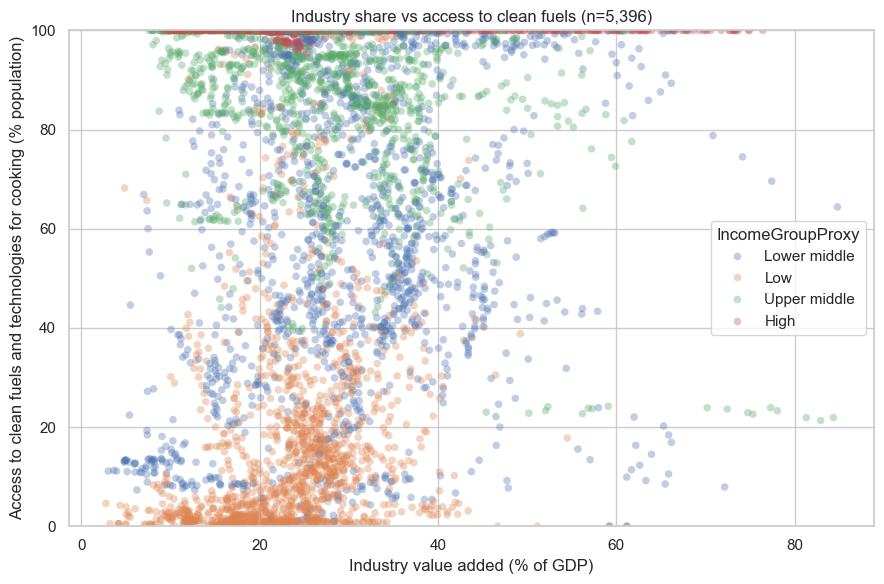

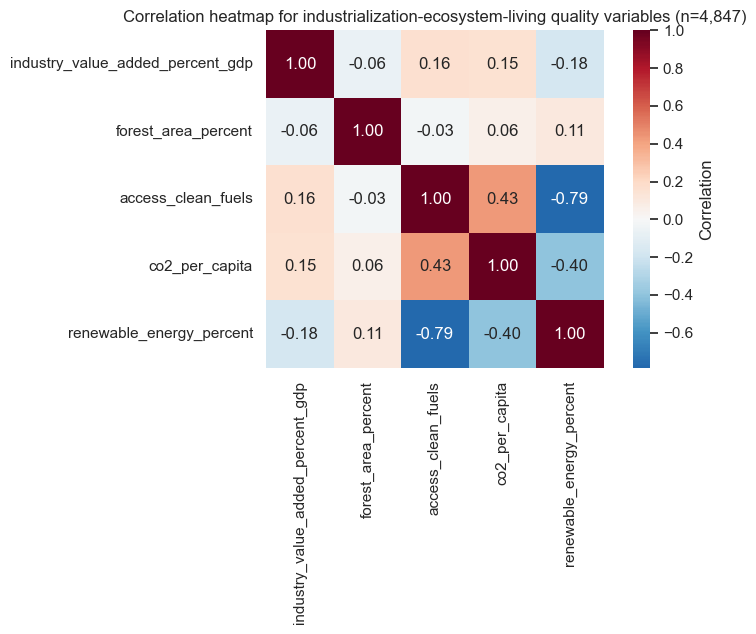

In [26]:
# Mục tiêu 3A: Industry vs Forest (hexbin) + xu hướng median theo năm
df_tradeoff = analysis_df[["Year", "industry_value_added_percent_gdp", "forest_area_percent", "access_clean_fuels", "IncomeGroupProxy"]].copy()

pair_a = df_tradeoff[["industry_value_added_percent_gdp", "forest_area_percent"]].dropna().copy()
if len(pair_a) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    hb = axes[0].hexbin(
        pair_a["industry_value_added_percent_gdp"],
        pair_a["forest_area_percent"],
        gridsize=35,
        cmap="YlGnBu",
        mincnt=1,
    )
    cb = fig.colorbar(hb, ax=axes[0])
    cb.set_label("Point density")
    axes[0].set_title(f"Industry share vs forest area (hexbin, n={len(pair_a):,})")
    axes[0].set_xlabel("Industry value added (% of GDP)")
    axes[0].set_ylabel("Forest area (% of land area)")

    sample_scatter = pair_a.sample(min(len(pair_a), 8000), random_state=42)
    sns.scatterplot(
        data=sample_scatter,
        x="industry_value_added_percent_gdp",
        y="forest_area_percent",
        alpha=0.3,
        s=20,
        color="#4C72B0",
        linewidth=0,
        ax=axes[1],
    )
    axes[1].set_title("Scatter check for pattern and outliers")
    axes[1].set_xlabel("Industry value added (% of GDP)")
    axes[1].set_ylabel("Forest area (% of land area)")

    plt.suptitle("Mục tiêu 3A — Numerical × Numerical với dữ liệu dày", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Không đủ dữ liệu cho Mục tiêu 3A.")

ts_tradeoff = (
    df_tradeoff.groupby("Year", as_index=False)[["industry_value_added_percent_gdp", "forest_area_percent"]]
    .median()
    .dropna(subset=["industry_value_added_percent_gdp", "forest_area_percent"], how="all")
)

if len(ts_tradeoff) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
    sns.lineplot(data=ts_tradeoff, x="Year", y="industry_value_added_percent_gdp", marker="o", color="#8172B2", ax=axes[0])
    axes[0].set_title("Median industry share over time")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Industry value added (% of GDP)")

    sns.lineplot(data=ts_tradeoff, x="Year", y="forest_area_percent", marker="o", color="#55A868", ax=axes[1])
    axes[1].set_title("Median forest area over time")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Forest area (% of land area)")

    plt.suptitle("Mục tiêu 3A (bổ trợ) — Time-series median theo năm", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Không đủ dữ liệu time-series cho Mục tiêu 3A.")

# Mục tiêu 3B: Industry vs Access clean fuels
pair_b = df_tradeoff[["industry_value_added_percent_gdp", "access_clean_fuels", "IncomeGroupProxy"]].dropna().copy()
if len(pair_b) > 0:
    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=pair_b.sample(min(len(pair_b), 10000), random_state=42),
        x="industry_value_added_percent_gdp",
        y="access_clean_fuels",
        hue="IncomeGroupProxy",
        alpha=0.35,
        s=30,
        linewidth=0,
    )
    plt.ylim(0, 100)
    plt.title(f"Industry share vs access to clean fuels (n={len(pair_b):,})")
    plt.xlabel("Industry value added (% of GDP)")
    plt.ylabel("Access to clean fuels and technologies for cooking (% population)")
    plt.tight_layout()
    plt.show()
else:
    print("Không đủ dữ liệu cho Mục tiêu 3B.")

# Mục tiêu 3C: Heatmap tương quan đa biến
corr_cols = [
    "industry_value_added_percent_gdp",
    "forest_area_percent",
    "access_clean_fuels",
    "co2_per_capita",
    "renewable_energy_percent",
]
corr_df = analysis_df[corr_cols].dropna().copy()
if len(corr_df) > 0:
    corr_mat = corr_df.corr(numeric_only=True)
    plt.figure(figsize=(8.5, 6.5))
    sns.heatmap(
        corr_mat,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        square=True,
        cbar_kws={"label": "Correlation"},
    )
    plt.title(f"Correlation heatmap for industrialization-ecosystem-living quality variables (n={len(corr_df):,})")
    plt.tight_layout()
    plt.show()
else:
    print("Không đủ dữ liệu cho heatmap Mục tiêu 3C.")

#### Insight phân tích (Mục tiêu 3A — Industry share vs Forest area)
- **Observation:** Quan hệ tuyến tính giữa tỷ trọng công nghiệp và diện tích rừng rất yếu, dữ liệu phân tán rộng.
- **Evidence:** Tương quan Pearson = **-0.025**; trung vị industry share = **25.27%**; trung vị forest area = **30.96%**; P10–P90 forest area = **2.33%–63.83%**.
- **Interpretation:** Mức công nghiệp hóa không giải thích trực tiếp biến động diện tích rừng ở quy mô toàn mẫu; vai trò chính có thể đến từ thể chế đất đai, chính sách bảo tồn và cấu trúc kinh tế khác biệt.
- **Implication:** Chính sách môi trường không nên suy diễn đơn giản rằng tăng công nghiệp luôn kéo giảm rừng; cần gắn quy hoạch công nghiệp với quản trị tài nguyên theo bối cảnh từng quốc gia.
- **Limitation:** Hexbin/scatter phản ánh tương quan tĩnh, chưa nắm bắt độ trễ tác động theo thời gian và khác biệt cấp vùng trong từng quốc gia.

#### Insight phân tích (Mục tiêu 3A bổ trợ — Time-series median)
- **Observation:** Industry share trung vị giảm nhẹ theo chuỗi, forest area trung vị cũng giảm nhẹ.
- **Evidence:** Industry median: **25.64% → 25.33%** (**-0.31 điểm %**); forest median: **32.00% → 31.08%** (**-0.92 điểm %**); biên độ industry median: **23.64%–26.81%**.
- **Interpretation:** Chuyển dịch cơ cấu toàn mẫu diễn ra chậm; thay đổi trong công nghiệp hóa không đi cùng cải thiện rõ ràng về chỉ số rừng ở mức trung vị.
- **Implication:** Cần phối hợp chính sách công nghiệp xanh và bảo tồn hệ sinh thái dài hạn thay vì kỳ vọng hiệu ứng đồng biến/nghịch biến ngắn hạn.
- **Limitation:** Chỉ số trung vị theo năm có thể che lấp thay đổi mạnh ở nhóm quốc gia biên và không phản ánh phân bố đầy đủ.

#### Insight phân tích (Mục tiêu 3B — Industry share vs Access clean fuels)
- **Observation:** Quan hệ giữa công nghiệp hóa và tiếp cận nhiên liệu sạch là dương nhưng yếu.
- **Evidence:** Tương quan Pearson = **0.149**; trung vị access clean fuels = **79.22%**; P10–P90 = **4.55%–100.00%**; tỷ lệ quan sát có access ≥ 90% là **41.7%**.
- **Interpretation:** Tiếp cận nhiên liệu sạch chịu ảnh hưởng bởi hạ tầng và chính sách xã hội năng lượng nhiều hơn là chỉ mức công nghiệp hóa.
- **Implication:** Chương trình chuyển dịch năng lượng cần nhánh chính sách riêng cho năng lượng hộ gia đình (clean cooking), không thể thay thế bằng mục tiêu công nghiệp đơn thuần.
- **Limitation:** Biến access có trần tự nhiên 100% gây hiệu ứng nén dữ liệu; tương quan tuyến tính có thể đánh giá thấp quan hệ phi tuyến.

#### Insight phân tích (Mục tiêu 3C — Heatmap tương quan đa biến)
- **Observation:** Tồn tại nhóm quan hệ mạnh giữa các biến năng lượng và chất lượng sống; nổi bật nhất là renewable và access clean fuels theo chiều âm.
- **Evidence:** Cặp mạnh nhất theo |r|: **renewable_energy_percent vs access_clean_fuels (r = -0.786)**; số quan sát ma trận tương quan: **n = 4,847**; độ lớn tương quan trung bình |r| giữa các cặp là **0.237**.
- **Interpretation:** Các biến trong hệ sinh thái năng lượng thể hiện cấu trúc liên hệ phức tạp; một chỉ số “xanh” không đại diện đầy đủ cho toàn bộ chiều cạnh chuyển dịch.
- **Implication:** Theo dõi chính sách cần dashboard đa chỉ số (renewable, emissions, clean fuels, structure) thay vì tối ưu một KPI duy nhất.
- **Limitation:** Heatmap dựa trên mẫu giao nhau (complete-case) nên có thể lệch mẫu; kết quả tương quan không xác định chiều tác động nhân quả.